In [1]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm
import matplotlib as mpl

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=mpl.colormaps['Set2'].colors)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d
from tqdm import tqdm
# from scipy.integrate import simps as simpson
from scipy.integrate import simpson
from scipy.special import i0

## Zeus setup

In [3]:
import zeus21

UserParams = zeus21.User_Parameters(precisionboost=1.2)

ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

In [4]:
CosmoParams_input_zeus = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False, CORRECTED_XI_ETA=False
    )
ClassyCosmo_zeus = zeus21.runclass(CosmoParams_input_zeus)

In [5]:
CosmoParams_zeus = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input_zeus, ClassyCosmo_zeus)
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
HMFintclass_zeus = zeus21.HMF_interpolator(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)

In [6]:
### POP II quantities first

################################
### Model Parameters
astromodel = 0            # ASTRO MODEL: 0 for GALUMI-like, 1 for 21cmfast-like, default 0
accretion_model = 0       # ACCRETION MODEL: 0 for exponential, 1 for EPS, default EXP

################################
### SFR(Mh) Parameteres
alphastar = 0.5          # alphastar powerlaw index for low masses, default 0.5
betastar = -0.5           # betastar powerlaw index for high masses, default -0.5
epsstar = 10**-1.             # epsilonstar = fstar at Mc
Mc = 3e11                 # Pivot mass at which the power law cuts for model 0, default Mc = 3e11
dlog10epsstardz = 0.0     # dlog10epsilonstar/dz, default 0

################################
### Escape fraction parameters
fesc10 = 0.1              # fesc(M) parameter. Power law normalized (fesc10) at M=1e10 Msun with index alphaesc
alphaesc = 0.0
L40_xray = 10**0.5        # L40_xray: soft-band (E<2 keV) lum/SFR in Xrays in units of 10^40 erg/s/(Msun/yr)
E0_xray = 500.            # E0_xray: minimum energy in eV
alpha_xray = -1.0         # Xray SED power-law index
Emax_xray_norm=2000       # max energy in eV to normalize SED. Keep at 2000 eV normally

################################
### LyA parameters
Nalpha_lyA_II = 9690      # number of Pop II photons between LyA and Ly Cont. per baryon (from BL05)
Nalpha_lyA_III = 17900    # number of Pop III photons between LyA and Ly Cont. per baryon value of 17900 is from Klessen & Glover 2023 (2303.12500), table A2

################################
### MTURN Parameters: 
Mturn_fixed = None        # Mturn_fixed: None if use Matom(z) at each z, Some value if fixed Mturn
FLAG_MTURN_SHARP= False   # Mturn_sharp: False if regular exponential cutoff, True if sharp cutoff, active only if Mturn_fixed is on

################################
### UVLF Parameters
C0dust = 4.43             # DUST PARAMETERS FOR UVLFs
C1dust = 1.99
sigmaUV = 0.5             # stochasticity (gaussian rms) in the halo-galaxy connection P(MUV | Mh) - TODO: only used in UVLF not sfrd

################################
ZMIN = 10.0               # down to which z we compute the evolution



################################
# Pop III Quantities
alphastar_III = 0 
betastar_III = 0
fstar_III = 10**(-3.0)
Mc_III = 1e7
dlog10epsstardz_III = 0.0

fesc7_III = 10**(-1.35)
alphaesc_III = -0.3
L40_xray_III = 10**0.5
alpha_xray_III = -1.0


USE_POPIII = True
USE_LW_FEEDBACK = True

A_LW = 2.0
beta_LW = 0.6

A_vcb = 1.0
beta_vcb = 1.8


#set up your astro parameters too, here the peak of f*(Mh) as an example

AstroParams = zeus21.Astro_Parameters(UserParams,
                                      CosmoParams_zeus, 
                                      astromodel = astromodel, 
                                      accretion_model = accretion_model,
                                      
                                      alphastar = alphastar, 
                                      betastar = betastar, 
                                      epsstar = epsstar, 
                                      Mc = Mc, 
                                      dlog10epsstardz = dlog10epsstardz,
                                      
                                      fesc10 = fesc10, 
                                      alphaesc = alphaesc,
                                      L40_xray = L40_xray, 
                                      E0_xray = E0_xray, 
                                      alpha_xray = alpha_xray, 
                                      Emax_xray_norm = Emax_xray_norm, 
                                      
                                      Nalpha_lyA_II = Nalpha_lyA_II, 
                                      Nalpha_lyA_III = Nalpha_lyA_III,
                                      
                                      Mturn_fixed = Mturn_fixed, 
                                      FLAG_MTURN_SHARP = FLAG_MTURN_SHARP,

                                      C0dust = C0dust, 
                                      C1dust = C1dust,
                                      sigmaUV = sigmaUV,
                                     
                                     
                                      USE_POPIII = USE_POPIII, 
                                      USE_LW_FEEDBACK = USE_LW_FEEDBACK,

                                      alphastar_III = alphastar_III, 
                                      betastar_III = betastar_III,
                                      fstar_III = fstar_III,
                                      Mc_III = Mc_III,
                                      dlog10epsstardz_III = dlog10epsstardz_III,

                                      fesc7_III = fesc7_III,
                                      alphaesc_III = alphaesc_III,
                                      L40_xray_III = L40_xray_III,
                                      alpha_xray_III = alpha_xray_III,
                                               
                                      A_LW = A_LW,
                                      beta_LW = beta_LW,
                                      
                                      A_vcb = A_vcb,
                                      beta_vcb = beta_vcb
                                               )

# CoeffStructure = zeus21.get_T21_coefficients(UserParams, CosmoParams, ClassyCosmo, AstroParams, HMFintclass, zmin=ZMIN)
CoeffStructure_zeus = zeus21.get_T21_coefficients(UserParams, CosmoParams_zeus, ClassyCosmo_zeus, AstroParams, HMFintclass_zeus,
                                                    zmin=ZMIN)

## Compute $\xi_\eta$ and $\xi_U$

In [7]:
# Real run values from xi_U_comparison.ipynb
lambda1 = 1.1819690031628485
lambda2 = 1.1819690031628485
lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)

In [8]:
xiEta_para = CorrFClass_zeus.xiEtaPar_RR_CF
xiEta_perp = CorrFClass_zeus.xiEtaPerp_RR_CF
xiEta_para_normalized = xiEta_para / np.nanmax(xiEta_para)
xiEta_perp_normalized = xiEta_perp / np.nanmax(xiEta_perp)
xiEta = (xiEta_para_normalized + 2 * xiEta_perp_normalized) / 3

xi_U_zeus = (1 - lambda_term * xiEta) ** (-3/2) - 1
xi_U_zeus_normalized = xi_U_zeus / np.nanmax(xi_U_zeus)

xi_U_aniso = ((1 - lambda_term * xiEta_para) * (1 - lambda_term * xiEta_perp) ** 2) ** (-1/2) - 1
xi_U_aniso_normalized = xi_U_aniso / np.nanmax(xi_U_aniso)

### $\xi_\eta$ plot

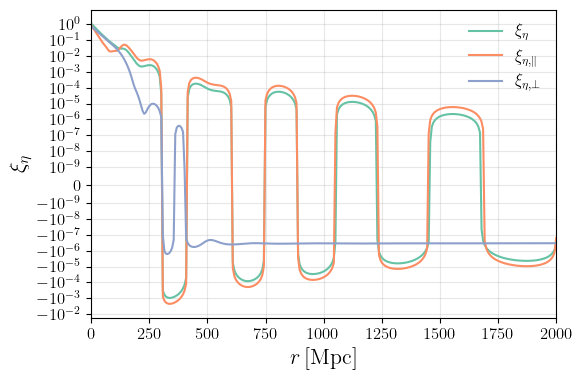

In [17]:
rlist = np.asarray(CosmoParams_zeus._Rtabsmoo)
R1_choose = 0
R2_choose = 0


xiEta_choose = xiEta[R1_choose, R2_choose, :]
xiEta_para_choose = xiEta_para[R1_choose, R2_choose, :]
xiEta_perp_choose = xiEta_perp[R1_choose, R2_choose, :]

r_dense = np.linspace(rlist.min(), rlist.max(), 300)
xiEta_choose_dense = interp1d(rlist, xiEta_choose, kind='cubic')(r_dense)
xiEta_para_choose_dense = interp1d(rlist, xiEta_para_choose, kind='cubic')(r_dense)
xiEta_perp_choose_dense = interp1d(rlist, xiEta_perp_choose, kind='cubic')(r_dense)

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(r_dense, xiEta_choose_dense, label=r'$\xi_\eta$')
ax.plot(r_dense, xiEta_para_choose_dense, label=r'$\xi_{\eta,\parallel}$')
ax.plot(r_dense, xiEta_perp_choose_dense, label=r'$\xi_{\eta,\perp}$')
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_\eta$", fontsize=16)
ax.legend(frameon=False)
ax.set_yscale('symlog', linthresh=1e-9)
ax.set_xlim(0, 2000)
ax.grid(True, alpha=0.3)

### $\xi_U$ plot

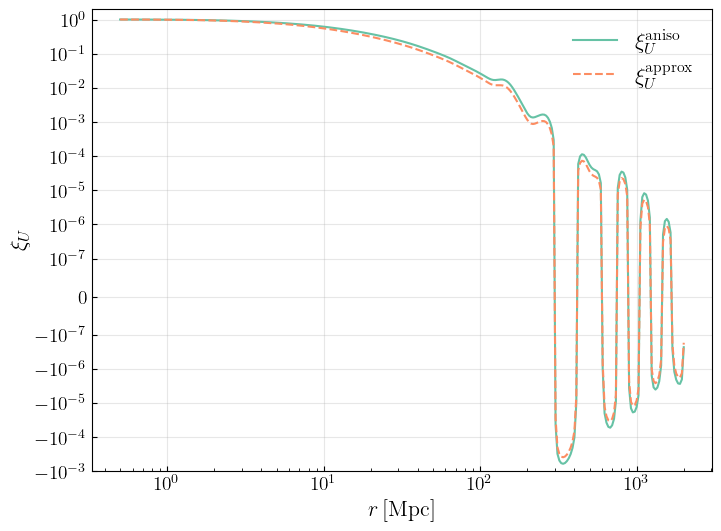

In [18]:
xi_U_zeus_normalized_choose = xi_U_zeus_normalized[R1_choose, R2_choose, :]
xi_U_aniso_normalized_choose = xi_U_aniso_normalized[R1_choose, R2_choose, :]

r_dense_log = np.geomspace(rlist.min(), rlist.max(), 300)
xi_U_aniso_normalized_choose_dense = interp1d(rlist, xi_U_aniso_normalized_choose, kind='cubic')(r_dense_log)
xi_U_zeus_normalized_choose_dense = interp1d(rlist, xi_U_zeus_normalized_choose, kind='cubic')(r_dense_log)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(r_dense_log, xi_U_aniso_normalized_choose_dense, label=r'$\xi_U^{\mathrm{aniso}}$')
ax.plot(r_dense_log, xi_U_zeus_normalized_choose_dense, linestyle='--', label=r"$\xi_U^{\mathrm{approx}}$")
ax.set_ylim(-1e-3, 2)
ax.set_xscale("log")
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_U$", fontsize=16)
ax.legend(frameon=False, fontsize=16)
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.grid(True, alpha=0.3)